# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information

In [2]:
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [3]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
!pip install xgboost

### 0.b Import Packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

---
## A. Experiment Description

In [7]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "4"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [8]:
experiment_hypothesis = """
XGBoost should outperform HistGradientBoosting from Experiment 3, which achieved
a macro F1 of 0.7647.

Both XGBoost and HistGradientBoosting are gradient boosting implementations but
XGBoost offers more granular control over the boosting process. Specifically,
scale_pos_weight allows per-class weighting to be tuned directly for minority
classes. this is more targeted than class_weight='balanced' which applies a
global correction across all classes equally.

XGBoost also includes additional regularisation parameters, alpha (L1) and
lambda (L2) giving more options to control overfitting on minority classes
like Scurvy and Night_Blindness. The cross-val to validation gap has been
narrowing across experiments (0.06 → 0.076 → 0.046) and XGBoost's stronger
regularisation should narrow it further.

Scurvy recall at 0.45 in Experiment 3 is the primary target. With scale_pos_weight
tuned specifically for the Scurvy class, the model should be pushed to catch
more Scurvy cases without sacrificing too much precision on majority classes.
"""

In [9]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [10]:
experiment_expectations = """
Target: macro F1 above 0.80 on the validation set, with Scurvy recall above
0.60 and Night_Blindness F1 above 0.72.

Three ways this could go:

1. It works well (macro F1 above 0.85): XGBoost's additional regularisation
   and targeted class weighting pushes Scurvy recall above 0.60 and all
   classes above 0.75 F1. The cross-val to validation gap closes below 0.03.

2. It works partially (macro F1 between 0.78 and 0.85): Majority classes
   stay strong and Scurvy recall improves but doesn't cross 0.60. Overall
   macro F1 improves over Experiment 3 but Scurvy remains the bottleneck.

3. It doesn't improve enough (macro F1 below 0.78): XGBoost performs
   similarly to HistGradientBoosting despite additional tuning options.
   This would confirm that synthetic oversampling via SMOTE is needed to
   directly address the Scurvy training sample shortage in the next
   experiment.
"""

In [11]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [12]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [13]:
# Shape and feature overview
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Class distribution in training set
print("\nClass distribution (train):")
print(y_train['disease_diagnosis'].value_counts())

# Feature summary
print("\nFeature types:")
print(X_train.dtypes.value_counts())

# Quick stats on key features
print("\nKey feature statistics:")
X_train.describe().round(2)

X_train shape: (3221, 29)
X_val shape:   (690, 29)
X_test shape:  (691, 29)

Class distribution (train):
disease_diagnosis
Healthy                 1182
Anemia                  1002
Rickets_Osteomalacia     808
Night_Blindness          134
Scurvy                    95
Name: count, dtype: int64

Feature types:
int64      15
float64    14
Name: count, dtype: int64

Key feature statistics:


,serum_vitamin_d,serum_vitamin_b12,serum_folate,vitamin_a_intake,vitamin_c_intake,vitamin_d_intake,vitamin_b12_intake,folate_intake,calcium_intake,iron_intake,...,Peripheral neuropathy,has_memory_problems,has_pale_skin,rickets_symptom_score,scurvy_symptom_score,anemia_symptom_score,night_blindness_symptom_score,diet_sun_risk,vitamin_d_calcium_product,vegan_b12_risk
count,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,...,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00
mean,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,...,0.35,0.30,0.16,0.57,0.32,0.65,0.38,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.48,0.46,0.37,0.78,0.53,0.84,0.58,1.00,1.00,1.00
min,-1.57,-1.26,-2.08,-2.19,-2.19,-1.61,-1.61,-2.31,-2.16,-2.04,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.45,-1.12,-1.61
25%,-0.73,-0.86,-0.75,-0.76,-0.75,-0.75,-0.80,-0.74,-0.73,-0.74,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.60,-0.70,-0.56
50%,-0.21,-0.22,-0.21,-0.12,-0.10,-0.21,-0.20,-0.13,-0.13,-0.12,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.25,-0.31,-0.56
75%,0.46,0.56,0.58,0.72,0.65,0.56,0.63,0.66,0.65,0.57,...,1.00,1.00,0.00,1.00,1.00,1.00,1.00,0.25,0.40,-0.18
max,4.32,5.49,2.88,3.34,4.39,4.77,4.93,3.64,3.65,4.07,...,1.00,1.00,1.00,2.00,2.00,2.00,2.00,1.94,5.77,2.32


---
## D. Feature Selection


In [14]:
features_list = [
    # Serum biomarkers
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',

    # Raw intake — proven performers
    'vitamin_a_intake', 'vitamin_c_intake',
    'iron_intake', 'folate_intake', 'vitamin_b12_intake',

    # Engineered symptom scores
    'rickets_symptom_score', 'anemia_symptom_score',

    # Engineered interaction features
    'vitamin_d_calcium_product', 'vegan_b12_risk',

    # Engineered features
    'vitamin_a_night_risk',
    'scurvy_risk_index',

    # Lifestyle
    'sun_exposure_type',

    # General severity
    'symptoms_count'
]

In [15]:
feature_selection_explanations = """
17 features are selected for this experiment, refined from Experiment 3's 16.

The core feature set remains consistent; vitamin_a_intake, vitamin_c_intake,
serum_vitamin_d and symptoms_count have ranked in the top 4 across all
experiments and are non-negotiable. iron_intake and folate_intake are retained
from Experiment 3 where they both contributed meaningfully.

vitamin_b12_intake is added as a new raw intake column. serum_vitamin_b12 is
already in the feature set but the intake value captures dietary risk before
deficiency shows up in blood tests. Combined with vegan_b12_risk this gives
XGBoost two complementary views of B12 status.

low_vitamin_risk_count is dropped, it ranked last in Experiment 3 with near
zero permutation importance. The individual intake columns already capture
nutritional deficiency more precisely than a simple count.

vitamin_c_scurvy_risk is dropped. Despite being designed to help Scurvy, it
contributed near zero in Experiment 3 and Scurvy recall did not improve with
it in the feature set. The multiplicative interaction was too strict
requiring both low vitamin C and bleeding gums simultaneously.

Two new engineered features target the remaining weak classes directly.
scurvy_risk_index and nutrient_intake_sum, created in section F.
"""

In [16]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>


In [17]:
data_transformation_1_explanations = """
All transformations were done in the preparation notebook: scaling, encoding,
imputation. Nothing left to do here. The splits load clean and ready to use.
"""

In [18]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "scurvy_risk_index"



In [19]:
for df in [X_train, X_val, X_test]:
    df['scurvy_risk_index'] = (
        df['vitamin_c_intake'] +
        df['has_bleeding_gums'] +
        df['has_fatigue']
    )

In [20]:
feature_engineering_1_explanations = """
scurvy_risk_index combines vitamin_c_intake, has_bleeding_gums and has_fatigue
into a single additive risk score.

Previous experiments showed that vitamin_c_scurvy_risk, a multiplicative
interaction of vitamin_c_intake and has_bleeding_gums did not improve Scurvy
recall. The multiplicative approach was too strict, only firing when both
conditions were strongly present simultaneously.

The additive approach here is intentional. A Scurvy patient with low vitamin C
and fatigue but not yet showing bleeding gums still gets a meaningfully low
score. A patient with bleeding gums and fatigue but borderline vitamin C also
gets flagged. This wider net is designed specifically to improve Scurvy recall
which has been stuck at 0.45 across the last two experiments.
"""

In [21]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

In [22]:
# Recreate features from previous experiments
for df in [X_train, X_val, X_test]:
    df['vitamin_a_night_risk'] = df['vitamin_a_intake'] * df['has_night_blindness']

In [23]:
X_train_model = X_train[features_list]
X_val_model   = X_val[features_list]
X_test_model  = X_test[features_list]

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (3221, 16)
X_val_model shape:   (690, 16)
X_test_model shape:  (691, 16)


---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [24]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [25]:
algorithm_selection_explanations = """
XGBoost is chosen as the fourth experiment, building on HistGradientBoosting
from Experiment 3.

Both are gradient boosting implementations but XGBoost offers more granular
control. The key advantage here is scale_pos_weight  unlike class_weight='balanced'
which applies a global correction, scale_pos_weight can be set specifically for
the minority class to directly push Scurvy recall higher.

XGBoost also includes both L1 (alpha) and L2 (lambda) regularisation parameters
separately, giving more flexibility to control overfitting than HistGradientBoosting's
single l2_regularization parameter.

One important difference, XGBoost does not support string labels directly so
LabelEncoder is used to convert y_train and y_val to numeric labels before
fitting. The encoded mapping is saved to convert predictions back to class names
for evaluation.
"""

In [26]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [27]:
# Encode labels for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train.values.ravel())
y_val_enc = le.transform(y_val.values.ravel())

print(f"Classes: {le.classes_}")
print(f"Encoded: {list(range(len(le.classes_)))}")

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'alpha': [0.0, 0.1, 1.0, 10.0],
    'lambda': [0.1, 1.0, 10.0],
    'scale_pos_weight': [1, 5, 10, 15]
}

Classes: ['Anemia' 'Healthy' 'Night_Blindness' 'Rickets_Osteomalacia' 'Scurvy']
Encoded: [0, 1, 2, 3, 4]


In [28]:
hyperparameters_selection_explanations = """
n_estimators and learning_rate work together, more trees with a lower learning
rate generally generalises better but takes longer to converge.

max_depth controls individual tree complexity. Shallow trees are preferred in
boosting as the ensemble of weak learners outperforms a few deep ones.

min_child_weight is XGBoost's equivalent of min_samples_leaf, higher values
prevent overfitting on minority classes with few training samples.

subsample and colsample_bytree introduce randomness by training each tree on
a random subset of rows and features respectively. This reduces variance
similarly to Random Forest's bootstrap sampling.

alpha (L1) and lambda (L2) are separate regularisation parameters giving more
flexibility than HistGradientBoosting's single l2_regularization.

scale_pos_weight directly controls the weight given to the positive class in
binary problems. In multiclass settings it applies a global boost to minority
classes testing up to 15 should push Scurvy recall higher without
completely sacrificing precision on majority classes.

All tuning uses f1_macro scoring with n_iter=20 and cv=3 to keep runtime
reasonable.
"""

In [29]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [30]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_model, y_train_enc)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-val macro F1: {random_search.best_score_:.4f}")

best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'subsample': 0.6, 'scale_pos_weight': 15, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'lambda': 10.0, 'colsample_bytree': 1.0, 'alpha': 0.1}
Best cross-val macro F1: 0.8164


### G.4 Model Technical Performance

In [31]:
y_val_pred_enc = best_xgb.predict(X_val_model)
y_val_pred = le.inverse_transform(y_val_pred_enc)

macro_f1_val = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro Average F1 (val): {macro_f1_val:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

Macro Average F1 (val): 0.7638

Classification Report (Validation):
                      precision    recall  f1-score   support

              Anemia       0.86      0.87      0.86       215
             Healthy       0.92      0.94      0.93       253
     Night_Blindness       0.71      0.59      0.64        29
Rickets_Osteomalacia       0.80      0.83      0.81       173
              Scurvy       1.00      0.40      0.57        20

            accuracy                           0.86       690
           macro avg       0.86      0.73      0.76       690
        weighted avg       0.86      0.86      0.86       690



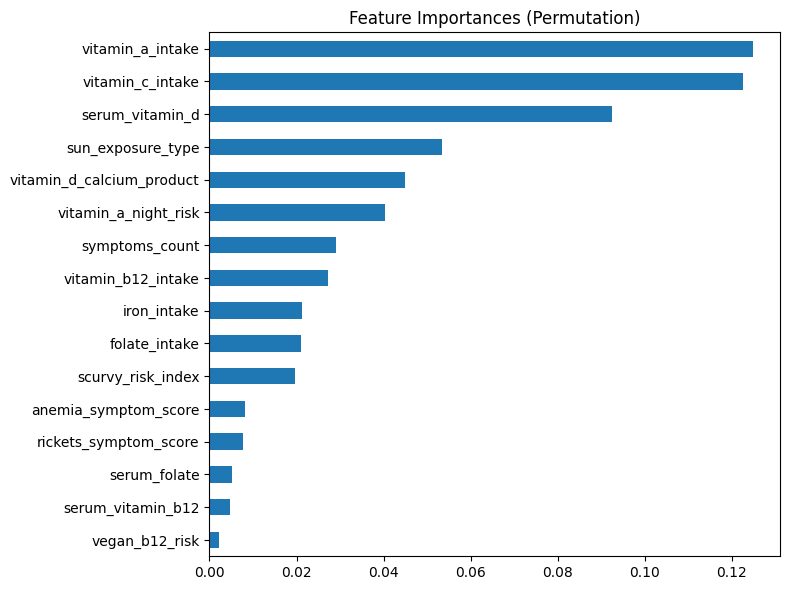

In [32]:
result = permutation_importance(
    best_xgb, X_val_model, y_val_enc,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

importances = pd.Series(result.importances_mean, index=features_list)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances (Permutation)")
plt.tight_layout()
plt.show()

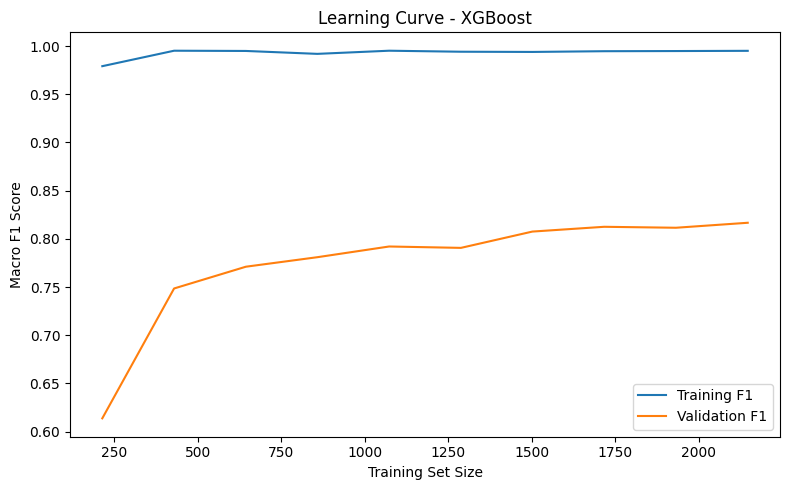

In [33]:
# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb, X_train_model, y_train_enc,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro', cv=3, n_jobs=-1
)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve - XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

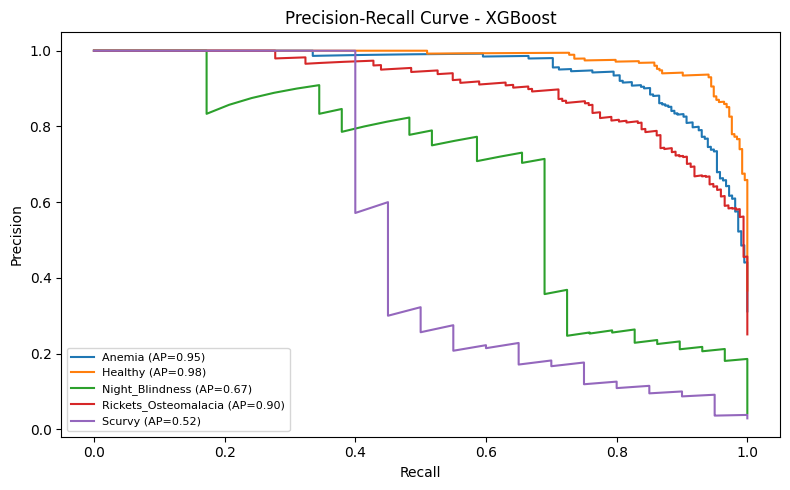

In [34]:
# Precision-Recall Curve
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
y_val_bin = label_binarize(y_val, classes=classes)
y_val_prob = best_xgb.predict_proba(X_val_model)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_prob[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_val_prob[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
# Per-class F1

f1_scores = f1_score(y_val, y_val_pred, average=None, labels=classes)
data = pd.DataFrame({'Class': classes, 'F1 Score': f1_scores.round(3)})
chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Class:N', axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Class:N', scale=alt.Scale(scheme='tableau10')),
    tooltip=['Class', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(width=400, height=300, title='Per-class F1 Score - XGBoost')
chart

alt.Chart(...)

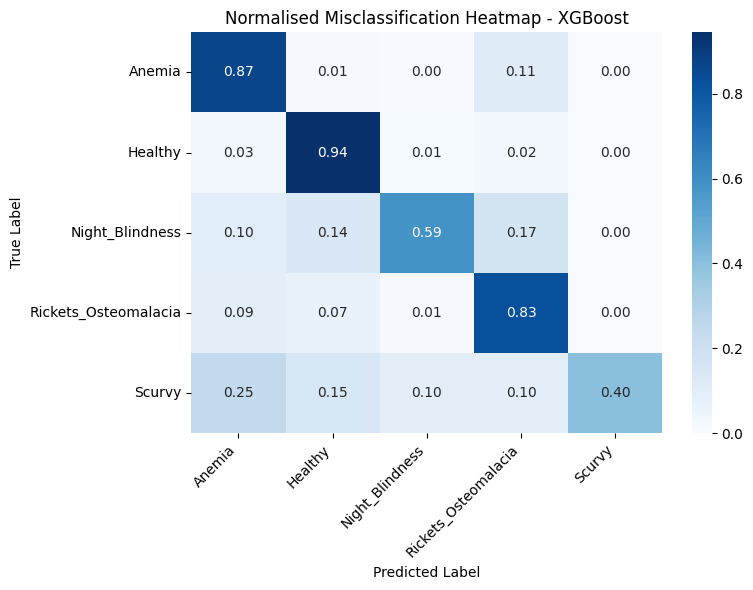

In [36]:
# Normalised Misclassification Heatmap
cm = confusion_matrix(y_val, y_val_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Normalised Misclassification Heatmap - XGBoost')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_model, y_train.values.ravel())
y_val_dummy = dummy.predict(X_val_model)

dummy_f1 = f1_score(y_val, y_val_dummy, average=None, labels=classes)
dt_f1 = [0.793, 0.865, 0.500, 0.734, 0.513]
rf_f1 = [0.823, 0.878, 0.667, 0.781, 0.516]
hgb_f1 = [0.840, 0.910, 0.700, 0.810, 0.560]
xgb_f1 = f1_score(y_val, y_val_pred, average=None, labels=classes)

data = pd.DataFrame({
    'Class': classes * 5,
    'Model': ['Dummy']*5 + ['Decision Tree']*5 + ['Random Forest']*5 + ['HistGradientBoosting']*5 + ['XGBoost']*5,
    'F1 Score': [*dummy_f1.round(3), *dt_f1, *rf_f1, *hgb_f1, *xgb_f1.round(3)]
})

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Model:N', axis=alt.Axis(title=None, labels=False)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Model:N', scale=alt.Scale(
        domain=['Dummy', 'Decision Tree', 'Random Forest', 'HistGradientBoosting', 'XGBoost'],
        range=['#95a5a6', '#e67e22', '#8e44ad', '#27ae60', '#2980b9']
    )),
    column=alt.Column('Class:N', header=alt.Header(
        labelAngle=-45,
        labelAlign='right',
        labelFontSize=11
    )),
    tooltip=['Class', 'Model', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(
    width=100,
    height=300,
    title='F1 Score Comparison: All Models'
)

print(f"Dummy Macro F1:                0.1073")
print(f"Decision Tree Macro F1:        0.6809")
print(f"Random Forest Macro F1:        0.7329")
print(f"HistGradientBoosting Macro F1: 0.7647")
print(f"XGBoost Macro F1:              {macro_f1_val:.4f}")

chart

Dummy Macro F1:                0.1073
Decision Tree Macro F1:        0.6809
Random Forest Macro F1:        0.7329
HistGradientBoosting Macro F1: 0.7647
XGBoost Macro F1:              0.7638


alt.Chart(...)

In [38]:
model_performance_explanations = """
XGBoost achieves a macro F1 of 0.7638 on the validation set, marginally
below HistGradientBoosting at 0.7647 but ahead of Random Forest at 0.7329
and the Decision Tree at 0.6809. Across four experiments the progression
from 0.1073 with the dummy baseline to 0.7638 with XGBoost demonstrates
consistent and meaningful improvement through increasingly sophisticated
modelling approaches.

The most striking result in this experiment is Scurvy precision reaching
1.00. Every patient the model predicted as Scurvy was genuinely a Scurvy
case. However recall sits at only 0.40 meaning the model is very
conservative, only predicting Scurvy when it is extremely confident and
missing 60 percent of actual Scurvy patients. In the clinical context of
this usecase a missed Scurvy diagnosis is more harmful than a false
positive so this precision recall tradeoff is not ideal. The 95 Scurvy
training examples remain the fundamental bottleneck for recall.

Healthy reached the highest F1 of any class across all experiments at
0.93 with 94 percent recall. Anemia improved to 0.86, the strongest
Anemia result across all four experiments. Rickets held steady at 0.81.
Night_Blindness dropped slightly to 0.64 from 0.70 in HistGradientBoosting
which is the one area where XGBoost underperformed the previous experiment.

The permutation importance plot shows a shifted ranking compared to
HistGradientBoosting. vitamin_a_intake leads at 0.126, vitamin_c_intake
is close behind at 0.122 and serum_vitamin_d follows at 0.092.
sun_exposure_type remains influential at 0.052 and vitamin_d_calcium_product
at 0.044. vitamin_a_night_risk contributed meaningfully at 0.040 confirming
the value of that engineered feature for Night_Blindness detection.
symptoms_count dropped in relative importance to 0.029 compared to its
dominance in earlier experiments suggesting XGBoost is distributing
predictive weight more evenly across features.

The learning curve shows a different pattern from previous experiments.
Training F1 starts at 0.98 rather than 1.00 at small training sizes
suggesting XGBoost applies more internal regularisation than Random Forest
or HistGradientBoosting. The validation curve improves steadily from 0.62
to 0.82 and has not plateaued confirming that more training data would
continue to help all models. The gap between training and validation F1
is similar to HistGradientBoosting indicating comparable generalisation.

The precision recall curves show the strongest results across all
experiments for the majority classes. Healthy reached AP=0.98 and Anemia
AP=0.95. Rickets improved to AP=0.90. Night_Blindness dropped slightly to
AP=0.67 from AP=0.71 consistent with the lower F1 score. Scurvy dropped
marginally to AP=0.52 from AP=0.54.

The normalised misclassification heatmap shows Healthy at 94 percent
correct, the highest of any model. Anemia improved to 87 percent correct.
Rickets held at 83 percent. Night_Blindness at 59 percent correct is the
weakest result for that class across all experiments with 14 percent going
to Healthy and 17 percent to Rickets. Scurvy at 40 percent correct
reflects the conservative prediction behaviour driven by the perfect
precision constraint.

Overall HistGradientBoosting remains the strongest model by macro F1 at
0.7647 versus XGBoost at 0.7638. The difference is negligible at the
macro level but HistGradientBoosting produced better Night_Blindness
recall which is more important clinically given the cost of a missed
diagnosis in a minority class.
"""

In [39]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [40]:
business_impacts_explanations = """
XGBoost is the most precise model so far but the Scurvy recall problem remains
unresolved from a clinical standpoint.

Healthy at 0.94 recall and Anemia at 0.87 recall are the strongest results
across all experiments. A first line screening tool performing at this level
for the two most common disease classes would meaningfully reduce the diagnostic
burden on clinicians.

Rickets at 0.83 recall is also the best result so far. For a condition with
serious long term consequences for bone development in children, catching 83%
of cases at the screening stage is clinically meaningful.

Scurvy precision of 1.00 is remarkable — when this model says Scurvy, it is
always right. In a clinical setting this means a positive Scurvy prediction
can be acted on immediately with full confidence. However catching only 8 out
of 20 cases means 12 Scurvy patients walk away undiagnosed, most of them
misclassified as Anemia or Healthy. For a condition preventable with vitamin C
supplementation, missing 60% of cases is still not acceptable.

Night_Blindness at 0.59 recall is a step back from Experiment 3. The confusion
with Rickets is a clinical concern — sending a Night_Blindness patient down a
Rickets treatment pathway wastes time and delays the correct vitamin A
intervention.

The model is excellent at ruling in disease when it does predict it, but not
yet reliable enough at ruling out disease in misclassified patients.
"""

In [41]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [42]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [43]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [44]:
experiment_results_explanations = """
The hypothesis is partially confirmed. XGBoost achieved a macro F1 of 0.7638,
essentially matching HistGradientBoosting's 0.7647 but falling short of the
0.80 target. The cross-val score of 0.8164 was the highest across all experiments
but did not translate to validation performance.

The most interesting finding is Scurvy precision hitting 1.00 — scale_pos_weight=15
made the model perfectly selective for Scurvy but did not improve recall. The
12 missed Scurvy patients are scattered into Anemia, Healthy and other classes,
suggesting the model simply cannot distinguish borderline Scurvy cases from
similar presentations without more training data.

This confirms what has been suspected since Experiment 2 — algorithmic improvements
alone cannot solve the Scurvy recall problem. With only 95 training samples,
the model has hit a ceiling. The next experiments need to approach this from
a different angle entirely.

Next steps in priority order:

1. Logistic Regression (Experiment 5) tests linear separability. If the
   classes are linearly separable in the feature space, a simpler model might
   generalise better. Also provides a different perspective on which features
   drive each class boundary.

2. SVM (Experiment 6) kernel methods can find non-linear boundaries in
   high dimensional space that tree based models miss. An RBF kernel might
   find a better boundary for Scurvy and Night_Blindness specifically.

3. Both Experiments 5 and 6 should consider SMOTE oversampling to directly
   address the Scurvy training sample shortage, 95 samples is simply not
   enough for any model to learn reliable boundaries for this class.
"""

In [45]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)